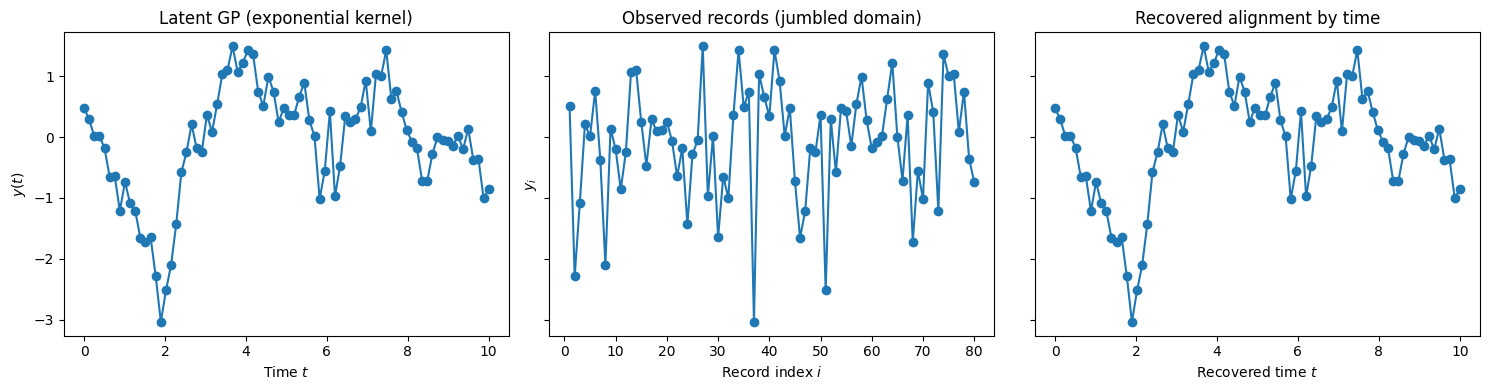

In [2]:
import numpy as np
import matplotlib.pyplot as plt

# -----------------------------
# 1. Simulate a GP time series
#    with exponential kernel
# -----------------------------
np.random.seed(2025)

n = 80
t_true = np.linspace(0, 10, n)  # true time grid

def exp_kernel(t, s, ell=1.0, sigma2=1.0):
    t = np.atleast_1d(t)[:, None]
    s = np.atleast_1d(s)[None, :]
    d = np.abs(t - s)
    return sigma2 * np.exp(-d / ell)

K = exp_kernel(t_true, t_true, ell=1.0, sigma2=1.0)
K += 1e-6 * np.eye(n)  # jitter

y_true = np.random.multivariate_normal(mean=np.zeros(n), cov=K)

# -----------------------------------
# 2. Jumble the domain (time points)
# -----------------------------------
perm = np.random.permutation(n)
t_jumbled = t_true[perm]
y_jumbled = y_true[perm]

# "Recovered" alignment (here we use the true permutation via sorting times)
perm_recovered = np.argsort(t_jumbled)
t_aligned = t_jumbled[perm_recovered]
y_aligned = y_jumbled[perm_recovered]

# -----------------------------
# 3. Make side-by-side plots
# -----------------------------
fig, axes = plt.subplots(1, 3, figsize=(15, 4), sharey=True)

# Panel 1: True latent GP as a function of time
axes[0].plot(t_true, y_true, marker='o', linestyle='-')
axes[0].set_title("Latent GP (exponential kernel)")
axes[0].set_xlabel("Time $t$")
axes[0].set_ylabel("$y(t)$")

# Panel 2: Jumbled observations vs record index
record_index = np.arange(1, n + 1)
axes[1].plot(record_index, y_jumbled, marker='o', linestyle='-')
axes[1].set_title("Observed records (jumbled domain)")
axes[1].set_xlabel("Record index $i$")
axes[1].set_ylabel("$y_i$")

# Panel 3: Re-aligned / recorded at proper time index
axes[2].plot(t_aligned, y_aligned, marker='o', linestyle='-')
axes[2].set_title("Recovered alignment by time")
axes[2].set_xlabel("Recovered time $t$")

plt.tight_layout()
plt.show()


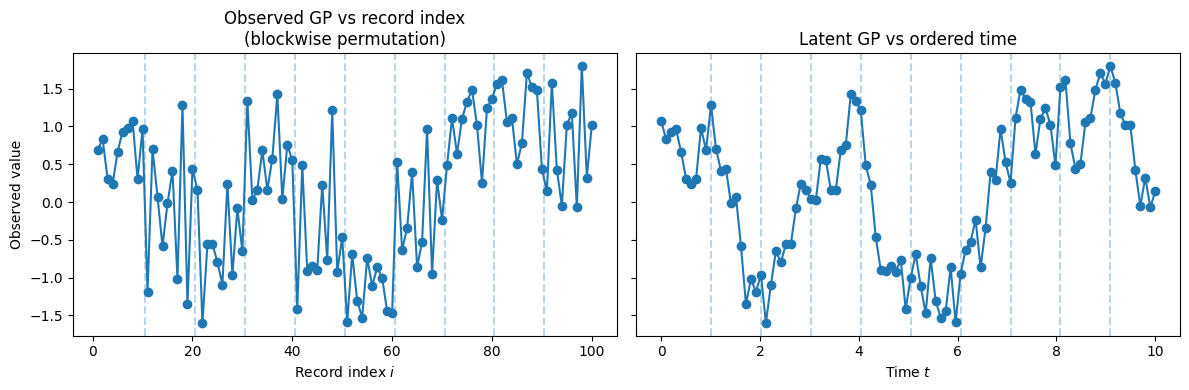

In [16]:
import numpy as np
import matplotlib.pyplot as plt

np.random.seed(2025)

# -----------------------------
# 1. Simulate GP with exponential kernel
# -----------------------------
n = 100
t_true = np.linspace(0, 10, n)  # true time grid

def exp_kernel(t, s, ell=1.0, sigma2=1.0):
    t = np.atleast_1d(t)[:, None]
    s = np.atleast_1d(s)[None, :]
    d = np.abs(t - s)
    return sigma2 * np.exp(-d / ell)

K = exp_kernel(t_true, t_true, ell=1.0, sigma2=1.0)
K += 0.005 * np.eye(n)  # jitter

y_true = np.random.multivariate_normal(mean=np.zeros(n), cov=K)

# -----------------------------
# 2. Blockwise permutation
#    - split into 10 blocks
#    - apply SAME permutation within each block
# -----------------------------
n_blocks = 10
block_size = n // n_blocks

# permutation within a block (0,...,9)
perm_block = np.random.permutation(block_size)

# build global permutation of length 100
perm = np.zeros(n, dtype=int)
for b in range(n_blocks):
    start = b * block_size
    perm[start:start + block_size] = start + perm_block

# observed values after blockwise permutation
y_obs = y_true[perm]

# -----------------------------
# 3. Plots:
#   (1) observed GP vs record index
#   (2) latent GP vs ordered time
# -----------------------------
fig, axes = plt.subplots(1, 2, figsize=(12, 4), sharey=True)

record_index = np.arange(1, n + 1)

# (1) Observed GP vs record index (blockwise permuted)
axes[0].plot(record_index, y_obs, marker='o', linestyle='-')
axes[0].set_title("Observed GP vs record index\n(blockwise permutation)")
axes[0].set_xlabel("Record index $i$")
axes[0].set_ylabel("Observed value")

# mark block boundaries on record index
for b in range(1, n_blocks):
    axes[0].axvline(b * block_size + 0.5, linestyle='--', alpha=0.3)

# (2) Latent GP vs ordered time (true curve)
axes[1].plot(t_true, y_true, marker='o', linestyle='-')
axes[1].set_title("Latent GP vs ordered time")
axes[1].set_xlabel("Time $t$")

# mark block boundaries in time
for b in range(1, n_blocks):
    t_boundary = t_true[b * block_size]
    axes[1].axvline(t_boundary, linestyle='--', alpha=0.3)

plt.tight_layout()
plt.show()


/var/folders/kj/tn21r9y15yz4_21vggchc7sc0000gp/T/ipykernel_348/3361425865.py:75: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


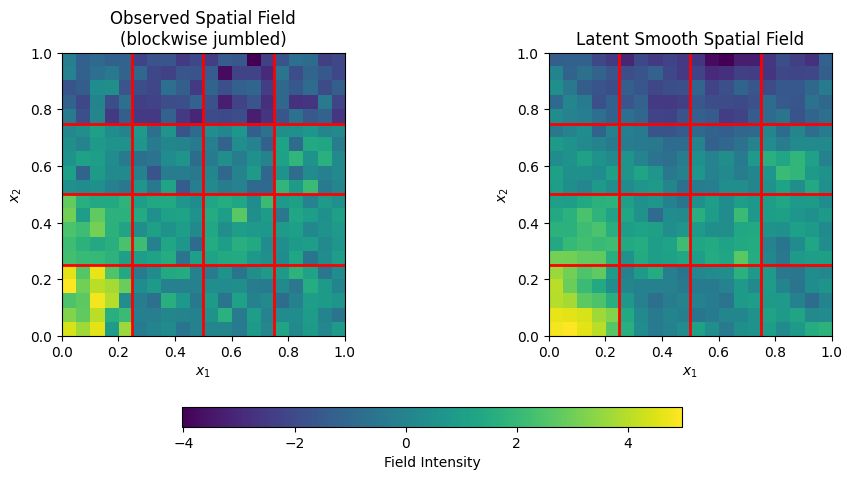

In [21]:
import numpy as np
import matplotlib.pyplot as plt

np.random.seed(2025)

# -----------------------------
# 1. Simulate a 2D GP on a grid
# -----------------------------
n_side = 20  # 20x20 grid
n = n_side * n_side

x1 = np.linspace(0, 1, n_side)
x2 = np.linspace(0, 1, n_side)
X1, X2 = np.meshgrid(x1, x2)

coords = np.column_stack([X1.ravel(), X2.ravel()])

def exp_kernel_2d(x, y, ell=0.2, sigma2=1.0):
    diff = x[:, None, :] - y[None, :, :]
    d = np.linalg.norm(diff, axis=2)
    return sigma2 * np.exp(-d / ell)

K = exp_kernel_2d(coords, coords, ell=1, sigma2=5.0)
K += 1e-6 * np.eye(n)

field_vec = np.random.multivariate_normal(np.zeros(n), K)
field_true = field_vec.reshape(n_side, n_side)

# -----------------------------
# 2. Local blockwise permutation
# -----------------------------
block_side = 5
n_blocks_per_side = n_side // block_side

perm_block = np.random.permutation(block_side * block_side)
field_obs = field_true.copy()

for bi in range(n_blocks_per_side):
    for bj in range(n_blocks_per_side):
        i0 = bi * block_side
        j0 = bj * block_side
        block = field_obs[i0:i0+block_side, j0:j0+block_side].ravel()
        block_perm = block[perm_block].reshape(block_side, block_side)
        field_obs[i0:i0+block_side, j0:j0+block_side] = block_perm

# -----------------------------
# 3. Plots with bold red grid lines
# -----------------------------
fig, axes = plt.subplots(1, 2, figsize=(10, 4))

# (1) Observed field
im0 = axes[0].imshow(field_obs, origin='lower', extent=[0,1,0,1])
axes[0].set_title("Observed Spatial Field\n(blockwise jumbled)")
axes[0].set_xlabel("$x_1$")
axes[0].set_ylabel("$x_2$")

# (2) True field
im1 = axes[1].imshow(field_true, origin='lower', extent=[0,1,0,1])
axes[1].set_title("Latent Smooth Spatial Field")
axes[1].set_xlabel("$x_1$")
axes[1].set_ylabel("$x_2$")

# ---- Draw bold red block boundaries ----
for ax in axes:
    for k in range(1, n_blocks_per_side):
        xb = k * (1.0 / n_blocks_per_side)
        ax.axvline(xb, color='red', linewidth=2.0)
        ax.axhline(xb, color='red', linewidth=2.0)

# ---- Centered shared colorbar ----
cbar_ax = fig.add_axes([0.25, -0.08, 0.5, 0.05])
cbar = fig.colorbar(im1, cax=cbar_ax, orientation='horizontal')
cbar.set_label("Field Intensity")

plt.tight_layout()
plt.show()


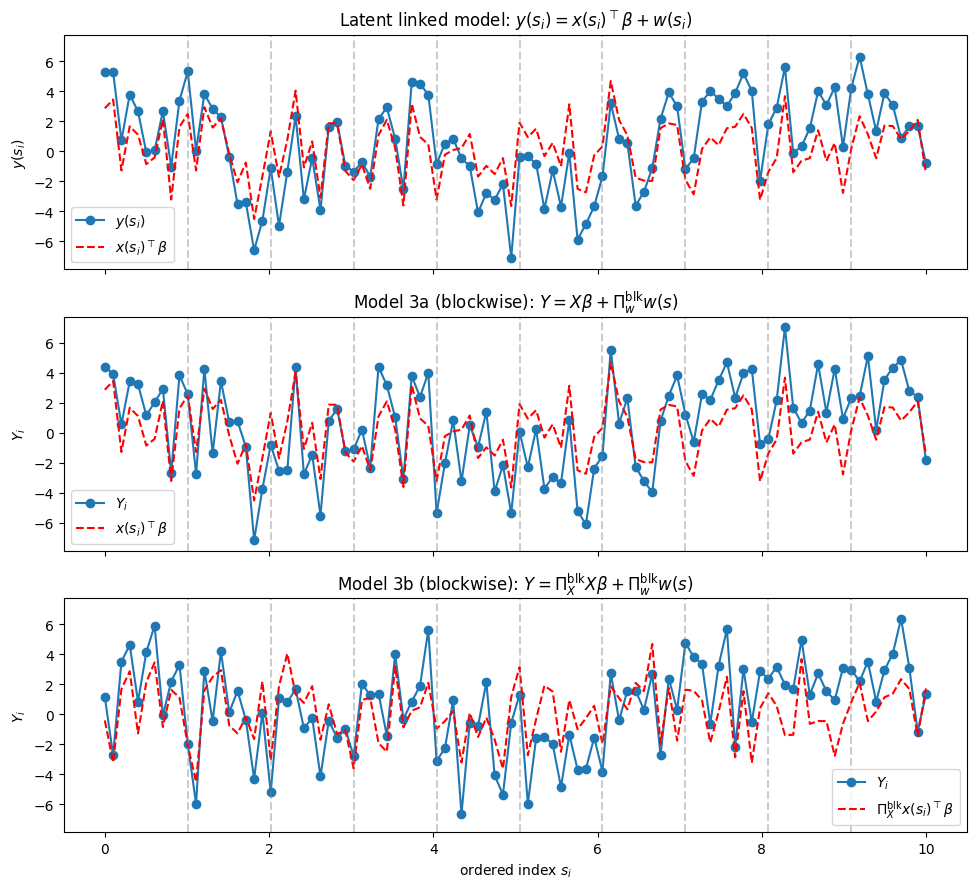

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

np.random.seed(2025)

# -----------------------------
# 1. Helpers
# -----------------------------
def exp_kernel(t, s, ell=1.0, sigma2=5.0):
    t = np.atleast_1d(t)[:, None]
    s = np.atleast_1d(s)[None, :]
    d = np.abs(t - s)
    return sigma2 * np.exp(-d / ell)

def random_derangement(m):
    """Return a random derangement of 0..m-1 (no fixed points)."""
    while True:
        p = np.random.permutation(m)
        if np.all(p != np.arange(m)):
            return p

# -----------------------------
# 2. Ordered index grid and GP error w(s)
# -----------------------------
n = 100
s = np.linspace(0, 10, n)  # ordered index {s_i}

K = exp_kernel(s, s, ell=1.0, sigma2=5.0)
K += 1e-6 * np.eye(n)

w = np.random.multivariate_normal(mean=np.zeros(n), cov=K)  # w(s_i)

# -----------------------------
# 3. Covariate x(s_i) and latent linked series
# -----------------------------
x = np.random.normal(loc=0.0, scale=1.0, size=n)
beta = 2.0

x_beta = x * beta                    # x(s_i)^T beta
y_linked = x_beta + w                # y(s_i) = x(s_i)^T beta + w(s_i)

# -----------------------------
# 4. Block-wise permutations (Model 3)
#    - different perms for w and X
# -----------------------------
n_blocks = 10
block_size = n // n_blocks

# block-wise derangement for w(s)
perm_block_w = random_derangement(block_size)
perm_blk_w = np.zeros(n, dtype=int)
for b in range(n_blocks):
    start = b * block_size
    perm_blk_w[start:start + block_size] = start + perm_block_w

# block-wise derangement for X (different from w)
perm_block_X = random_derangement(block_size)
perm_blk_X = np.zeros(n, dtype=int)
for b in range(n_blocks):
    start = b * block_size
    perm_blk_X[start:start + block_size] = start + perm_block_X

# -----------------------------
# 5. Model 3a: shuffle w(s) only (Π_w^{blk})
# -----------------------------
w_blk = w[perm_blk_w]                # Π_w^{blk} w(s)
y_model3a = x_beta + w_blk           # Y = X beta + Π_w^{blk} w(s)

# -----------------------------
# 6. Model 3b: shuffle X and w(s)
#    (Π_X^{blk} X beta + Π_w^{blk} w(s))
# -----------------------------
x_blk = x[perm_blk_X]                # Π_X^{blk} x(s)
x_beta_blk = x_blk * beta            # Π_X^{blk} x(s)^T beta
y_model3b = x_beta_blk + w_blk       # Y = Π_X^{blk} X beta + Π_w^{blk} w(s)

# -----------------------------
# 7. Plotting
# -----------------------------
fig, axes = plt.subplots(3, 1, figsize=(10, 9), sharex=True, sharey=True)

signal_color = "red"

def add_block_boundaries(ax):
    for b in range(1, n_blocks):
        ax.axvline(s[b * block_size], linestyle='--', color='gray', alpha=0.4)

# Panel 1: Latent linked model
axes[0].plot(s, y_linked, marker='o', linestyle='-', label=r'$y(s_i)$')
axes[0].plot(s, x_beta, linestyle='--', color=signal_color,
             label=r'$x(s_i)^\top\beta$')
axes[0].set_title(r'Latent linked model: $y(s_i)=x(s_i)^\top\beta + w(s_i)$')
axes[0].set_ylabel(r'$y(s_i)$')
add_block_boundaries(axes[0])
axes[0].legend()

# Panel 2: Model 3a – blockwise shuffled w(s) only
axes[1].plot(s, y_model3a, marker='o', linestyle='-', label=r'$Y_i$')
axes[1].plot(s, x_beta, linestyle='--', color=signal_color,
             label=r'$x(s_i)^\top\beta$')
axes[1].set_title(
    r'Model 3a (blockwise): $Y = X\beta + \Pi_w^{\mathrm{blk}} w(s)$'
)
axes[1].set_ylabel(r'$Y_i$')
add_block_boundaries(axes[1])
axes[1].legend()

# Panel 3: Model 3b – blockwise shuffled X and w(s)
axes[2].plot(s, y_model3b, marker='o', linestyle='-', label=r'$Y_i$')
axes[2].plot(s, x_beta_blk, linestyle='--', color=signal_color,
             label=r'$\Pi_X^{\mathrm{blk}} x(s_i)^\top\beta$')
axes[2].set_title(
    r'Model 3b (blockwise): $Y = \Pi_X^{\mathrm{blk}} X\beta + \Pi_w^{\mathrm{blk}} w(s)$'
)
axes[2].set_xlabel(r'ordered index $s_i$ (time)')
axes[2].set_ylabel(r'$Y_i$')
add_block_boundaries(axes[2])
axes[2].legend()

plt.tight_layout()
plt.show()


/var/folders/kj/tn21r9y15yz4_21vggchc7sc0000gp/T/ipykernel_348/3695245715.py:146: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


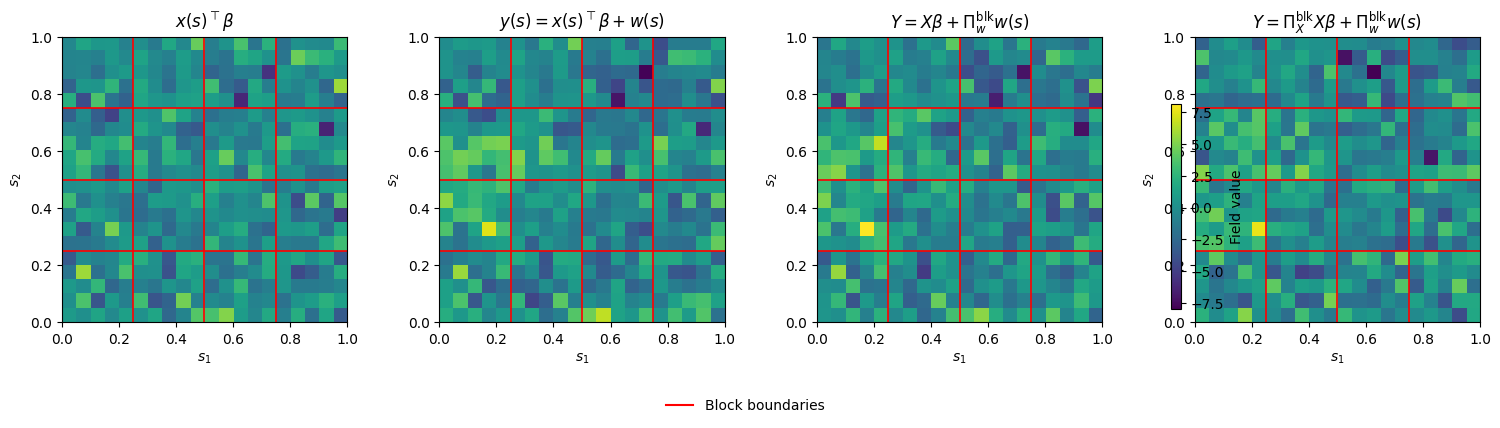

In [35]:
import numpy as np
import matplotlib.pyplot as plt

np.random.seed(2025)

# -----------------------------
# 1. Helpers
# -----------------------------
def exp_kernel_2d(x, y, ell=0.2, sigma2=1.0):
    diff = x[:, None, :] - y[None, :, :]
    d = np.linalg.norm(diff, axis=2)
    return sigma2 * np.exp(-d / ell)

def random_derangement(m):
    while True:
        p = np.random.permutation(m)
        if np.all(p != np.arange(m)):
            return p

# -----------------------------
# 2. Spatial grid + GP field w(s)
# -----------------------------
n_side = 20
n = n_side * n_side

x1 = np.linspace(0, 1, n_side)
x2 = np.linspace(0, 1, n_side)
X1, X2 = np.meshgrid(x1, x2)
coords = np.column_stack([X1.ravel(), X2.ravel()])

K = exp_kernel_2d(coords, coords, ell=0.2, sigma2=1.5)
K += 1e-6 * np.eye(n)
w_vec = np.random.multivariate_normal(mean=np.zeros(n), cov=K)
w_field = w_vec.reshape(n_side, n_side)

# -----------------------------
# 3. Covariate + linked model
# -----------------------------
x_cov = np.random.normal(size=n)
beta = 2.0

x_beta_vec = x_cov * beta
x_beta_field = x_beta_vec.reshape(n_side, n_side)

y_linked_vec = x_beta_vec + w_vec
y_linked_field = y_linked_vec.reshape(n_side, n_side)

# -----------------------------
# 4. Block-wise permutations
# -----------------------------
block_side = 5
n_blocks_per_side = n_side // block_side
block_size = block_side * block_side

perm_block_w = random_derangement(block_size)
perm_block_X = random_derangement(block_size)

# Apply blockwise permutation
def apply_block_perm(field, perm_block):
    field_perm = np.zeros_like(field)
    for bi in range(n_blocks_per_side):
        for bj in range(n_blocks_per_side):
            i0 = bi * block_side
            j0 = bj * block_side
            block = field[i0:i0+block_side, j0:j0+block_side]
            flat = block.ravel()
            flat_perm = flat[perm_block]
            field_perm[i0:i0+block_side, j0:j0+block_side] = \
                flat_perm.reshape(block_side, block_side)
    return field_perm

w_blk_field = apply_block_perm(w_field, perm_block_w)
x_beta_blk_field = apply_block_perm(x_beta_field, perm_block_X)

y_model3a_field = x_beta_field + w_blk_field
y_model3b_field = x_beta_blk_field + w_blk_field

# -----------------------------
# 5. Plotting
# -----------------------------
fig, axes = plt.subplots(1, 4, figsize=(15, 3.8))

all_vals = np.concatenate([
    x_beta_field.ravel(),
    y_linked_field.ravel(),
    y_model3a_field.ravel(),
    y_model3b_field.ravel()
])
vmin, vmax = all_vals.min(), all_vals.max()


def draw_block_boundaries(ax):
    for k in range(1, n_blocks_per_side):
        xb = k * (1.0 / n_blocks_per_side)
        ax.axvline(xb, color='red', linewidth=1.2)
        ax.axhline(xb, color='red', linewidth=1.2)

# Panel 1: x(s)^T beta
im0 = axes[0].imshow(x_beta_field, origin='lower',
                     extent=[0, 1, 0, 1], vmin=vmin, vmax=vmax)
axes[0].set_title(r'$x(s)^\top \beta$')
axes[0].set_xlabel(r'$s_1$')
axes[0].set_ylabel(r'$s_2$')
draw_block_boundaries(axes[0])

# Panel 2: y(s)
im1 = axes[1].imshow(y_linked_field, origin='lower',
                     extent=[0, 1, 0, 1], vmin=vmin, vmax=vmax)
axes[1].set_title(r'$y(s)=x(s)^\top\beta + w(s)$')
axes[1].set_xlabel(r'$s_1$')
axes[1].set_ylabel(r'$s_2$')
draw_block_boundaries(axes[1])

# Panel 3: Model 3a
im2 = axes[2].imshow(y_model3a_field, origin='lower',
                     extent=[0, 1, 0, 1], vmin=vmin, vmax=vmax)
axes[2].set_title(r'$Y = X\beta + \Pi_w^{\mathrm{blk}} w(s)$')
axes[2].set_xlabel(r'$s_1$')
axes[2].set_ylabel(r'$s_2$')
draw_block_boundaries(axes[2])

# Panel 4: Model 3b
im3 = axes[3].imshow(y_model3b_field, origin='lower',
                     extent=[0, 1, 0, 1], vmin=vmin, vmax=vmax)
axes[3].set_title(r'$Y = \Pi_X^{\mathrm{blk}} X\beta + \Pi_w^{\mathrm{blk}} w(s)$')
axes[3].set_xlabel(r'$s_1$')
axes[3].set_ylabel(r'$s_2$')
draw_block_boundaries(axes[3])

# Shared colorbar
cbar = fig.colorbar(im3, ax=axes.ravel().tolist(), shrink=0.7, location="right")
cbar.set_label("Field value")

# -----------------------------
# Add a clean COMMON legend
# -----------------------------
legend_lines = [
    plt.Line2D([0], [0], color='red', lw=1.5, label='Block boundaries')
]
fig.legend(handles=legend_lines,
           loc='lower center',
           bbox_to_anchor=(0.5, -0.08),
           ncol=1,
           frameon=False)

plt.tight_layout()
plt.subplots_adjust(bottom=0.17)  # Make space for legend
plt.show()


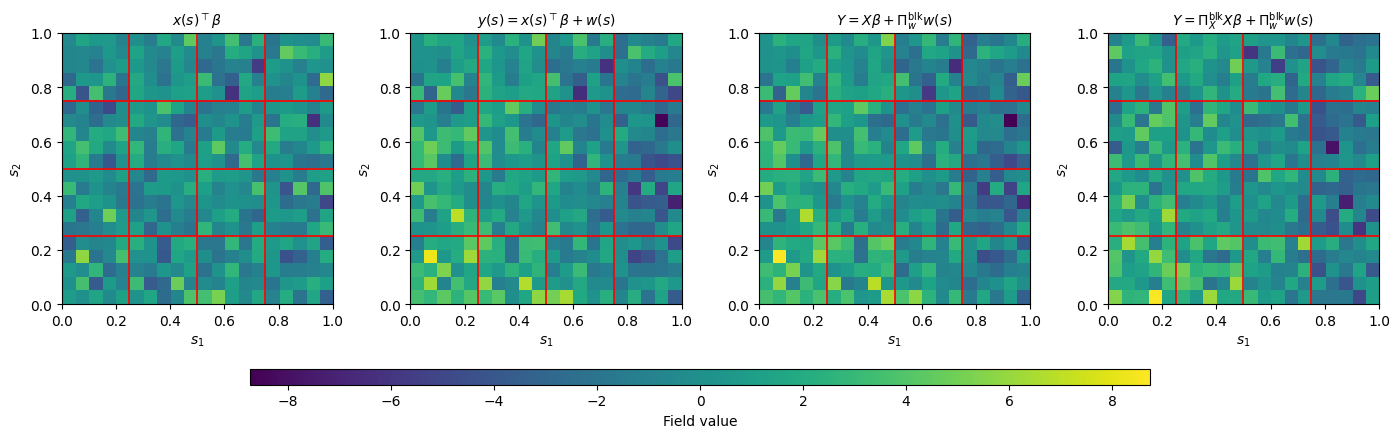

In [49]:
import numpy as np
import matplotlib.pyplot as plt

np.random.seed(2025)

# -----------------------------
# 1. Helpers
# -----------------------------
def matern32_kernel_2d(x, y, ell=0.25, sigma2=1.0):
    """
    Matérn ν=3/2 kernel in 2D:
    k(r) = sigma^2 (1 + sqrt(3) r / ell) exp(-sqrt(3) r / ell)
    """
    x = np.atleast_2d(x)
    y = np.atleast_2d(y)
    diff = x[:, None, :] - y[None, :, :]
    r = np.linalg.norm(diff, axis=2)
    sqrt3_r_over_ell = np.sqrt(3.0) * r / ell
    return sigma2 * (1.0 + sqrt3_r_over_ell) * np.exp(-sqrt3_r_over_ell)

def random_derangement(m):
    while True:
        p = np.random.permutation(m)
        if np.all(p != np.arange(m)):
            return p

def apply_block_perm(field, perm_block, block_side, n_blocks_side):
    field_perm = np.zeros_like(field)
    for bi in range(n_blocks_side):
        for bj in range(n_blocks_side):
            i0 = bi * block_side
            j0 = bj * block_side
            block = field[i0:i0+block_side, j0:j0+block_side]
            flat = block.ravel()
            flat_perm = flat[perm_block]
            field_perm[i0:i0+block_side, j0:j0+block_side] = \
                flat_perm.reshape(block_side, block_side)
    return field_perm

def draw_block_boundaries(ax, n_blocks_side):
    for k in range(1, n_blocks_side):
        xb = k * (1.0 / n_blocks_side)
        ax.axvline(xb, color='red', linewidth=1.2)
        ax.axhline(xb, color='red', linewidth=1.2)

# -----------------------------
# 2. Spatial grid + Matérn GP w(s)
# -----------------------------
n_side = 20            # 20x20 grid
n = n_side * n_side

s1 = np.linspace(0, 1, n_side)
s2 = np.linspace(0, 1, n_side)
S1, S2 = np.meshgrid(s1, s2)
coords = np.column_stack([S1.ravel(), S2.ravel()])  # (n, 2)

K = matern32_kernel_2d(coords, coords, ell=2, sigma2=16.0)
K += 1e-6 * np.eye(n)

w_vec = np.random.multivariate_normal(mean=np.zeros(n), cov=K)
w_field = w_vec.reshape(n_side, n_side)

# -----------------------------
# 3. Covariate x(s) + linked model
# -----------------------------
x_cov = np.random.normal(size=n)
beta = 2.0

x_beta_vec = x_cov * beta
x_beta_field = x_beta_vec.reshape(n_side, n_side)

y_linked_vec = x_beta_vec + w_vec
y_linked_field = y_linked_vec.reshape(n_side, n_side)

# -----------------------------
# 4. Block-wise permutations Π_w^{blk}, Π_X^{blk}
# -----------------------------
block_side = 5
n_blocks_side = n_side // block_side
block_size = block_side * block_side

perm_block_w = random_derangement(block_size)
perm_block_X = random_derangement(block_size)

w_blk_field      = apply_block_perm(w_field,      perm_block_w, block_side, n_blocks_side)
x_beta_blk_field = apply_block_perm(x_beta_field, perm_block_X, block_side, n_blocks_side)

# Model 3a: Y = Xβ + Π_w^{blk} w(s)
y_model3a_field = x_beta_field + w_blk_field
# Model 3b: Y = Π_X^{blk} Xβ + Π_w^{blk} w(s)
y_model3b_field = x_beta_blk_field + w_blk_field

# -----------------------------
# 5. Plotting
# -----------------------------
fig, axes = plt.subplots(1, 4, figsize=(15, 4))

all_vals = np.concatenate([
    x_beta_field.ravel(),
    y_linked_field.ravel(),
    y_model3a_field.ravel(),
    y_model3b_field.ravel()
])
vmin, vmax = all_vals.min(), all_vals.max()

panels = [
    (x_beta_field,     r'$x(s)^\top\beta$'),
    (y_linked_field,   r'$y(s)=x(s)^\top\beta+w(s)$'),
    (y_model3a_field,  r'$Y=X\beta+\Pi_w^{\mathrm{blk}}w(s)$'),
    (y_model3b_field,  r'$Y=\Pi_X^{\mathrm{blk}}X\beta+\Pi_w^{\mathrm{blk}}w(s)$'),
]

for ax, (field, title) in zip(axes, panels):
    im = ax.imshow(field, origin='lower',
                   extent=[0, 1, 0, 1], vmin=vmin, vmax=vmax)
    ax.set_title(title, fontsize=10)
    ax.set_xlabel(r'$s_1$')
    ax.set_ylabel(r'$s_2$')
    draw_block_boundaries(ax, n_blocks_side)

# Use tight_layout but reserve space at bottom for colorbar
plt.tight_layout(rect=[0.03, 0.12, 0.97, 1.0])

# Explicit colorbar axis BELOW all panels
cax = fig.add_axes([0.20, 0.04, 0.60, 0.04])  # [left, bottom, width, height] in figure coords
cbar = fig.colorbar(im, cax=cax, orientation='horizontal')
cbar.set_label("Field value")

plt.show()


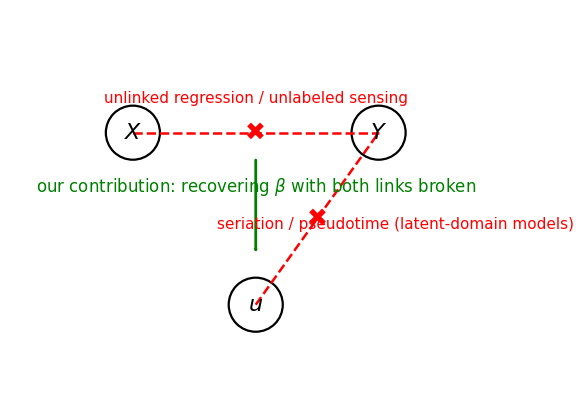

In [51]:
import matplotlib.pyplot as plt
from matplotlib.patches import Circle, FancyArrowPatch

fig, ax = plt.subplots(figsize=(6, 5))
ax.set_xlim(0, 10)
ax.set_ylim(0, 8)
ax.set_aspect('equal')
ax.axis('off')

# Node positions
pos_X = (2.5, 5.5)
pos_Y = (7.5, 5.5)
pos_u = (5.0, 2.0)

def draw_node(pos, label):
    circ = Circle(pos, radius=0.55, edgecolor='black', facecolor='white', linewidth=1.6)
    ax.add_patch(circ)
    ax.text(pos[0], pos[1], label, ha='center', va='center', fontsize=16)

def broken_link(p1, p2, label, text_offset):
    ax.plot([p1[0], p2[0]], [p1[1], p2[1]],
            linestyle='--', color='red', linewidth=1.8)
    mx = (p1[0] + p2[0]) / 2
    my = (p1[1] + p2[1]) / 2
    ax.text(mx, my, '✖', color='red', fontsize=18, ha='center', va='center')
    ax.text(mx + text_offset[0], my + text_offset[1],
            label, color='red', fontsize=11, ha='center')

def draw_focus_arrow(start, end, label):
    arrow = FancyArrowPatch(start, end, arrowstyle='->',
                            linewidth=2, edgecolor='green',
                            facecolor='green')
    ax.add_patch(arrow)
    mx = (start[0] + end[0]) / 2
    my = (start[1] + end[1]) / 2
    ax.text(mx, my + 0.3, label, color='green',
            fontsize=12, ha='center')

# Draw nodes
draw_node(pos_X, r"$X$")
draw_node(pos_Y, r"$Y$")
draw_node(pos_u, r"$u$")

# Broken links
broken_link(pos_X, pos_Y,
            "unlinked regression / unlabeled sensing",
            text_offset=(0, 0.6))

broken_link(pos_u, pos_Y,
            "seriation / pseudotime (latent-domain models)",
            text_offset=(1.6, -0.2))

# Our contribution (both missing)
draw_focus_arrow((5, 5.0), (5, 3.0),
                 r"our contribution: recovering $\beta$ with both links broken")

plt.tight_layout()
plt.savefig("joint_broken_links_diagram.png", dpi=300, bbox_inches='tight')
plt.savefig("joint_broken_links_diagram.pdf", bbox_inches='tight')
plt.show()


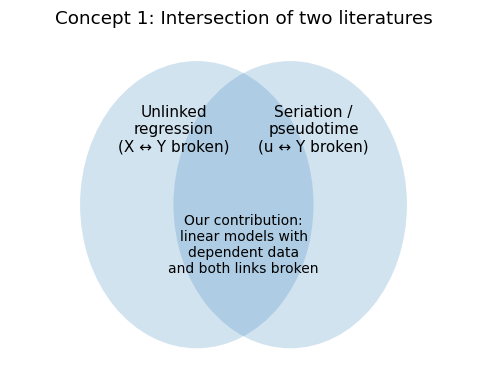

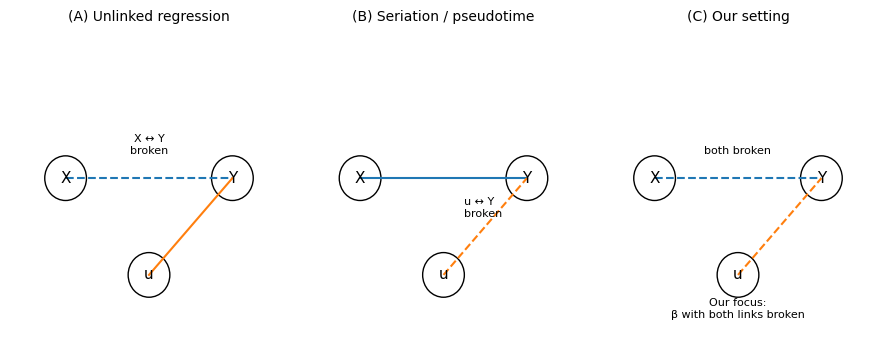

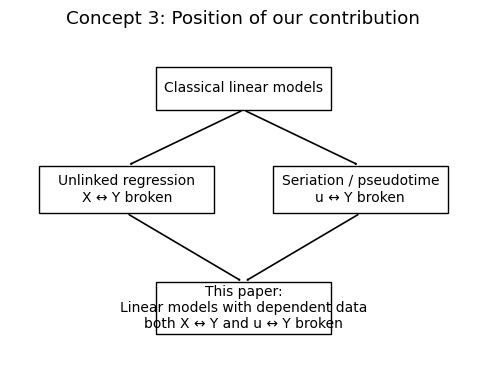

In [52]:
import matplotlib.pyplot as plt
from matplotlib.patches import Circle, Rectangle, FancyArrowPatch

plt.rcParams["font.size"] = 11

# -----------------------------
# Concept 1: Venn-style overlap
# -----------------------------
fig1, ax1 = plt.subplots(figsize=(5, 4))
ax1.set_xlim(0, 10)
ax1.set_ylim(0, 6)
ax1.axis('off')

# Two overlapping circles
circle1 = Circle((4, 3), 2.5, alpha=0.2)
circle2 = Circle((6, 3), 2.5, alpha=0.2)

ax1.add_patch(circle1)
ax1.add_patch(circle2)

ax1.text(3.5, 4.3,
         "Unlinked\nregression\n(X ↔ Y broken)",
         ha='center', va='center')
ax1.text(6.5, 4.3,
         "Seriation /\npseudotime\n(u ↔ Y broken)",
         ha='center', va='center')

ax1.text(5, 2.3,
         "Our contribution:\nlinear models with\ndependent data\nand both links broken",
         ha='center', va='center', fontsize=10)

ax1.set_title("Concept 1: Intersection of two literatures")
fig1.tight_layout()
fig1.savefig("concept1_venn.png", dpi=300, bbox_inches='tight')

# --------------------------------
# Concept 2: Three-panel mini-plot
# --------------------------------
fig2, axes2 = plt.subplots(1, 3, figsize=(9, 3.5))
titles = ["(A) Unlinked regression",
          "(B) Seriation / pseudotime",
          "(C) Our setting"]

for ax, title in zip(axes2, titles):
    ax.set_xlim(0, 4)
    ax.set_ylim(0, 4)
    ax.axis('off')
    ax.set_title(title, fontsize=10)

def node(ax, x, y, label):
    circ = Circle((x, y), 0.3, fill=False)
    ax.add_patch(circ)
    ax.text(x, y, label, ha='center', va='center', fontsize=11)

# Panel A: X-Y broken, u-Y intact
ax = axes2[0]
node(ax, 0.8, 2, "X")
node(ax, 3.2, 2, "Y")
node(ax, 2.0, 0.7, "u")
ax.plot([0.8, 3.2], [2, 2], linestyle='--')
ax.text(2.0, 2.3, "X ↔ Y\nbroken",
        ha='center', va='bottom', fontsize=8)
ax.plot([2.0, 3.2], [0.7, 2])  # intact u-Y

# Panel B: u-Y broken, X-Y intact
ax = axes2[1]
node(ax, 0.8, 2, "X")
node(ax, 3.2, 2, "Y")
node(ax, 2.0, 0.7, "u")
ax.plot([0.8, 3.2], [2, 2])  # intact X-Y
ax.plot([2.0, 3.2], [0.7, 2], linestyle='--')
ax.text(2.3, 1.6, "u ↔ Y\nbroken",
        ha='left', va='center', fontsize=8)

# Panel C: both broken (our focus)
ax = axes2[2]
node(ax, 0.8, 2, "X")
node(ax, 3.2, 2, "Y")
node(ax, 2.0, 0.7, "u")
ax.plot([0.8, 3.2], [2, 2], linestyle='--')
ax.plot([2.0, 3.2], [0.7, 2], linestyle='--')
ax.text(2.0, 2.3, "both broken",
        ha='center', va='bottom', fontsize=8)
ax.text(2.0, 0.1, "Our focus:\nβ with both links broken",
        ha='center', va='bottom', fontsize=8)

fig2.tight_layout()
fig2.savefig("concept2_three_panels.png", dpi=300, bbox_inches='tight')

# --------------------------------
# Concept 3: Flowchart-style plot
# --------------------------------
fig3, ax3 = plt.subplots(figsize=(5, 4))
ax3.set_xlim(0, 8)
ax3.set_ylim(0, 8)
ax3.axis('off')

def box(ax, x, y, w, h, text):
    rect = Rectangle((x, y), w, h, fill=False)
    ax.add_patch(rect)
    ax.text(x + w/2, y + h/2, text,
            ha='center', va='center', fontsize=10)

# Boxes
box(ax3, 2.5, 6.2, 3, 1,
    "Classical linear models")

box(ax3, 0.5, 3.8, 3, 1.1,
    "Unlinked regression\nX ↔ Y broken")

box(ax3, 4.5, 3.8, 3, 1.1,
    "Seriation / pseudotime\nu ↔ Y broken")

box(ax3, 2.5, 1.0, 3, 1.2,
    "This paper:\nLinear models with dependent data\nboth X ↔ Y and u ↔ Y broken")

# Arrows
arrow1 = FancyArrowPatch((4, 6.2), (2, 4.9),
                         arrowstyle='->', linewidth=1.2)
arrow2 = FancyArrowPatch((4, 6.2), (6, 4.9),
                         arrowstyle='->', linewidth=1.2)
arrow3 = FancyArrowPatch((2, 3.8), (4, 2.2),
                         arrowstyle='->', linewidth=1.2)
arrow4 = FancyArrowPatch((6, 3.8), (4, 2.2),
                         arrowstyle='->', linewidth=1.2)

for ar in [arrow1, arrow2, arrow3, arrow4]:
    ax3.add_patch(ar)

ax3.set_title("Concept 3: Position of our contribution")
fig3.tight_layout()
fig3.savefig("concept3_flowchart.png", dpi=300, bbox_inches='tight')

plt.show()


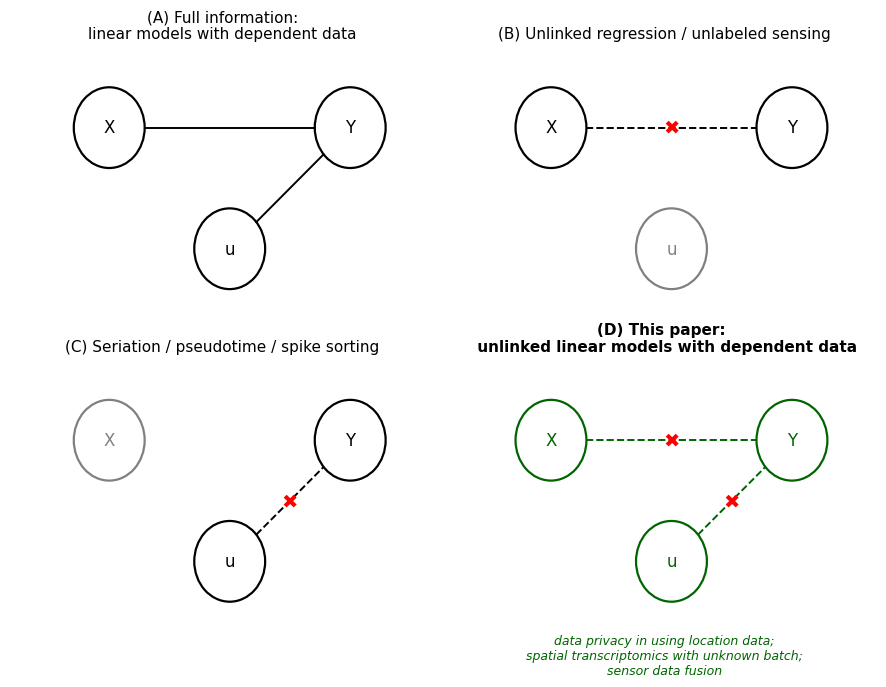

In [8]:
import matplotlib.pyplot as plt
from matplotlib.patches import Circle, FancyArrowPatch
import numpy as np

plt.rcParams["font.size"] = 11

# ------------------------------------------------------------
# Helpers
# ------------------------------------------------------------

def draw_node(ax, pos, label, radius=0.25, faded=False, color='black'):
    if faded:
        edgecolor = 'gray'
        textcolor = 'gray'
    else:
        edgecolor = color
        textcolor = color
    circ = Circle(pos, radius=radius, fill=False, edgecolor=edgecolor, linewidth=1.6)
    ax.add_patch(circ)
    ax.text(pos[0], pos[1], label, ha='center', va='center',
            fontsize=12, color=textcolor)

def draw_double_arrow(ax, p1, p2, radius=0.25, broken=False, color='black'):
    """
    Draw a double-headed arrow between two circular nodes, from edge to edge.
    p1, p2: (x, y) centers of the circles
    radius: circle radius
    """
    x1, y1 = p1
    x2, y2 = p2
    # direction vector from p1 to p2
    dx, dy = x2 - x1, y2 - y1
    dist = np.hypot(dx, dy)
    if dist == 0:
        return
    ux, uy = dx / dist, dy / dist

    # start and end points on circle boundaries
    start = (x1 + ux * radius, y1 + uy * radius)
    end   = (x2 - ux * radius, y2 - uy * radius)

    # line style
    if broken:
        style = "--"
    else:
        style = "-"

    # draw the main line (for visual thickness / dash pattern)
    ax.plot([start[0], end[0]], [start[1], end[1]],
            linestyle=style, color=color, linewidth=1.4)

    # double-headed arrow overlay (no dashes, just heads)
    arrow = FancyArrowPatch(
        start, end,
        arrowstyle="<->",
        linewidth=0.0,   # avoid double-drawing the shaft
        mutation_scale=12,
        color=color
    )
    ax.add_patch(arrow)

    # red X at midpoint if broken
    if broken:
        mx, my = (start[0] + end[0]) / 2, (start[1] + end[1]) / 2
        ax.text(mx, my, "✖", fontsize=14, ha='center', va='center', color='red')

# ------------------------------------------------------------
# Layout
# ------------------------------------------------------------
fig, axes = plt.subplots(2, 2, figsize=(9, 7))
axes = axes.ravel()

# Fixed node positions (same in all panels)
pos_X = (0.7, 1.1)
pos_Y = (2.4, 1.1)
pos_u = (1.55, 0.35)
radius = 0.25

# ------------------------------------------------------------
# Panel A: Full information
# ------------------------------------------------------------
ax = axes[0]
ax.set_xlim(0, 3)
ax.set_ylim(0, 1.6)
ax.axis('off')

draw_node(ax, pos_X, "X", radius=radius)
draw_node(ax, pos_Y, "Y", radius=radius)
draw_node(ax, pos_u, "u", radius=radius)

draw_double_arrow(ax, pos_X, pos_Y, radius=radius, broken=False)
draw_double_arrow(ax, pos_u, pos_Y, radius=radius, broken=False)

ax.set_title("(A) Full information:\nlinear models with dependent data", fontsize=11)

# ------------------------------------------------------------
# Panel B: Unlinked regression / unlabeled sensing
# ------------------------------------------------------------
ax = axes[1]
ax.set_xlim(0, 3)
ax.set_ylim(0, 1.6)
ax.axis('off')

draw_node(ax, pos_X, "X", radius=radius)
draw_node(ax, pos_Y, "Y", radius=radius)
draw_node(ax, pos_u, "u", radius=radius, faded=True)

draw_double_arrow(ax, pos_X, pos_Y, radius=radius, broken=True)

ax.set_title("(B) Unlinked regression / unlabeled sensing", fontsize=11)

# ------------------------------------------------------------
# Panel C: Seriation / pseudotime / spike sorting
# ------------------------------------------------------------
ax = axes[2]
ax.set_xlim(0, 3)
ax.set_ylim(0, 1.6)
ax.axis('off')

draw_node(ax, pos_X, "X", radius=radius, faded=True)
draw_node(ax, pos_Y, "Y", radius=radius)
draw_node(ax, pos_u, "u", radius=radius)

draw_double_arrow(ax, pos_u, pos_Y, radius=radius, broken=True)

ax.set_title("(C) Seriation / pseudotime / spike sorting", fontsize=11)

# ------------------------------------------------------------
# Panel D: Our scenario — both links broken
# ------------------------------------------------------------
ax = axes[3]
ax.set_xlim(0, 3)
ax.set_ylim(0, 1.6)
ax.axis('off')

# Use a different color for this panel (e.g., dark green)
our_color = "darkgreen"

draw_node(ax, pos_X, "X", radius=radius, color=our_color)
draw_node(ax, pos_Y, "Y", radius=radius, color=our_color)
draw_node(ax, pos_u, "u", radius=radius, color=our_color)

draw_double_arrow(ax, pos_X, pos_Y, radius=radius, broken=True, color=our_color)
draw_double_arrow(ax, pos_u, pos_Y, radius=radius, broken=True, color=our_color)

ax.set_title("(D) This paper: \n unlinked linear models with dependent data",
             fontsize=11, fontweight='bold')

# Applications under bottom in italics
ax.text(1.5, -0.10,
        "data privacy in using location data;\n"
        "spatial transcriptomics with unknown batch;\n"
        "sensor data fusion",
        ha='center', va='top', fontsize=9, fontstyle='italic', color=our_color)

fig.tight_layout()
fig.savefig("four_panel_links_story_clean.png", dpi=300, bbox_inches='tight')
fig.savefig("four_panel_links_story_clean.pdf", bbox_inches='tight')
plt.show()
